# SimReady Copilot — QLoRA Fine-Tune (Day 17)

**Goal:** Fine-tune Qwen2.5-3B-Instruct on 5 000 synthetic tool-call traces so the model
learns to call `analyze_geometry → suggest_fixes → lookup_standard` in the right order
and emit the Verdict/Issues/Fixes answer format.

**Runtime:** T4 GPU (free Colab tier). Expected ~2–3 hrs for 3 epochs.

**Before running:**
1. `Runtime → Change runtime type → T4 GPU`
2. Upload `data/fine_tune/train.jsonl` and `data/fine_tune/val.jsonl` to
   `MyDrive/simready/` in Google Drive (generated by `scripts/prep_finetune_dataset.py`).

**Output:** LoRA adapter saved to `MyDrive/simready/lora_adapter/` (resume-safe).

## 1 · Check GPU

In [ ]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected. Runtime → Change runtime type → T4 GPU.")

name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {name}  VRAM: {vram_gb:.1f} GB")
print(f"CUDA: {torch.version.cuda}  PyTorch: {torch.__version__}")

GPU: Tesla T4  VRAM: 15.6 GB
CUDA: 12.8  PyTorch: 2.10.0+cu128


## 2 · Install dependencies

Unsloth is the fastest QLoRA trainer on T4. `trl >= 0.8` for `SFTConfig`.

In [ ]:
%%capture
!pip install --upgrade unsloth trl>=0.8.0 peft transformers datasets accelerate bitsandbytes

In [ ]:
import unsloth, trl, transformers, peft
print(f"unsloth {unsloth.__version__}  trl {trl.__version__}  "
      f"transformers {transformers.__version__}  peft {peft.__version__}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
unsloth 2026.7.4  trl 0.24.0  transformers 5.5.0  peft 0.19.1


## 3 · Mount Drive + configure paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

DRIVE_ROOT    = Path("/content/drive/MyDrive/SimReady")
TRAIN_FILE    = DRIVE_ROOT / "train.jsonl"
VAL_FILE      = DRIVE_ROOT / "val.jsonl"
CHECKPOINT_DIR = str(DRIVE_ROOT / "checkpoints")
ADAPTER_DIR   = str(DRIVE_ROOT / "lora_adapter")

for f in [TRAIN_FILE, VAL_FILE]:
    if not f.exists():
        raise FileNotFoundError(
            f"{f} not found.\n"
            "Upload train.jsonl + val.jsonl from data/fine_tune/ to MyDrive/simready/"
        )

print(f"Train: {TRAIN_FILE}")
print(f"Val:   {VAL_FILE}")

Train: /content/drive/MyDrive/SimReady/train.jsonl
Val:   /content/drive/MyDrive/SimReady/val.jsonl


## 4 · Load dataset

In [ ]:
from datasets import load_dataset

raw = load_dataset(
    "json",
    data_files={"train": str(TRAIN_FILE), "validation": str(VAL_FILE)},
    split={"train": "train", "validation": "validation"},
)
train_raw, val_raw = raw["train"], raw["validation"]

print(f"Train: {len(train_raw):,}  Val: {len(val_raw):,}")
print("\nSample record keys:", list(train_raw[0].keys()))
print("\nCategory breakdown:")
from collections import Counter
print(Counter(train_raw["category"]))

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Train: 951  Val: 39

Sample record keys: ['id', 'category', 'token_estimate', 'messages']

Category breakdown:
Counter({'file_specific': 332, 'file_triage': 301, 'manufacturability': 154, 'mesh_prep': 129, 'standards': 35})


## 5 · Load Qwen2.5-3B-Instruct (4-bit, unsloth)

In [ ]:
from unsloth import FastLanguageModel, is_bfloat16_supported

MAX_SEQ_LEN = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-3B-Instruct",
    max_seq_length=MAX_SEQ_LEN,
    dtype=None,          # auto: bfloat16 on Ampere+, float16 on T4
    load_in_4bit=True,
)
print("Model loaded. dtype:", next(model.parameters()).dtype)

==((====))==  Unsloth 2026.7.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model loaded. dtype: torch.float16


## 6 · Apply LoRA adapter

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=32,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",  # reduces VRAM ~30%
    random_state=42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Unsloth 2026.7.4 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Trainable params: 29,933,568 / 1,830,055,936 (1.64%)


## 7 · Format data → chatml text

Manual formatter handles the `tool` role that `apply_chat_template` may not
support in all tokenizer versions. Produces the standard Qwen2.5 chatml:

```
<|im_start|>system\n...\n<|im_end|>
<|im_start|>user\n...\n<|im_end|>
<|im_start|>assistant\n<tool_call>\n{...}\n</tool_call>\n<|im_end|>
<|im_start|>tool\n<tool_response>\n{...}\n</tool_response>\n<|im_end|>
<|im_start|>assistant\nVerdict: ...\n<|im_end|>
```

In [ ]:
def to_chatml(messages: list[dict]) -> str:
    """Render messages list to Qwen2.5 chatml training string."""
    parts = []
    for msg in messages:
        role    = msg.get("role", "user")
        content = (msg.get("content") or "").strip()
        parts.append(f"<|im_start|>{role}\n{content}\n<|im_end|>")
    return "\n".join(parts)


def format_example(example: dict) -> dict:
    return {"text": to_chatml(example["messages"])}


train_ds = train_raw.map(format_example, remove_columns=train_raw.column_names)
val_ds   = val_raw.map(format_example,   remove_columns=val_raw.column_names)

# Sanity check: show one example
sample = train_ds[0]["text"]
print(f"Sample length: {len(sample)} chars")
print(sample[:800], "\n...[truncated]" if len(sample) > 800 else "")

Map:   0%|          | 0/951 [00:00<?, ? examples/s]

Map:   0%|          | 0/39 [00:00<?, ? examples/s]

Sample length: 5817 chars
<|im_start|>system
You are SimReady Copilot, an AI assistant for FEA (finite element analysis) pre-processing.
You help mechanical engineers analyze CAD geometry, find manufacturability issues, and suggest
text-only fixes (no part modification — that comes later).

You have three tools:
- analyze_geometry(step_path): run SimReady's pipeline on a CAD file. Returns a structured
  summary: status, complexity tier, score.overall, geometry counts, body_count,
  severity_counts, and findings (top-N by severity). Use this first whenever the user
  references a CAD file.
- suggest_fixes(findings): rank text-only fix suggestions from a findings list.
  Pass the findings array from analyze_geometry verbatim. Returns suggestions +
  severity_counts.
- lookup_standard(query, top_k=3): semantic search  
...[truncated]


In [ ]:
# Token length distribution
import numpy as np

def token_len(example):
    return {"n_tokens": len(tokenizer(example["text"])["input_ids"])}

train_toks = train_ds.map(token_len)
lens = train_toks["n_tokens"]

print(f"Token lengths — min:{min(lens)}  p25:{int(np.percentile(lens,25))}  "
      f"p50:{int(np.percentile(lens,50))}  p75:{int(np.percentile(lens,75))}  "
      f"p95:{int(np.percentile(lens,95))}  max:{max(lens)}")

over_limit = sum(1 for l in lens if l > MAX_SEQ_LEN)
if over_limit:
    print(f"WARNING: {over_limit} traces exceed {MAX_SEQ_LEN} tokens — they will be truncated.")
else:
    print(f"All traces fit within {MAX_SEQ_LEN} tokens.")

Map:   0%|          | 0/951 [00:00<?, ? examples/s]

Token lengths — min:914  p25:1350  p50:1548  p75:1750  p95:2070  max:2463


## 8 · Train

`train_on_responses_only` masks system/user/tool tokens so the loss is computed
only on `<|im_start|>assistant` turns. The model learns to generate tool calls
and final answers; it does not overfit to input format.

Checkpoints saved every 200 steps to Drive — resume-safe if session times out.

In [ ]:
from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import train_on_responses_only

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    args=SFTConfig(
        dataset_text_field="text",
        max_seq_length=MAX_SEQ_LEN,
        dataset_num_proc=2,
        # Batch: 2 × 8 grad-accum = 16 effective batch size
        per_device_train_batch_size=2,
        gradient_accumulation_steps=8,
        num_train_epochs=3,
        warmup_steps=50,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=50,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        # Eval + checkpoint every 200 steps
        eval_strategy="steps",
        eval_steps=200,
        save_strategy="steps",
        save_steps=200,
        save_total_limit=3,           # keep last 3 checkpoints on Drive
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        output_dir=CHECKPOINT_DIR,
        report_to="none",
    ),
)

# Mask non-assistant tokens from loss
trainer = train_on_responses_only(
    trainer,
    instruction_part="<|im_start|>user\n",
    response_part="<|im_start|>assistant\n",
)

print("Trainer ready. Starting training...")

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/951 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/39 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map:   0%|          | 0/951 [00:00<?, ? examples/s]

Map:   0%|          | 0/39 [00:00<?, ? examples/s]

Trainer ready. Starting training...


In [ ]:
trainer_stats = trainer.train()

print(f"\nTraining complete.")
print(f"  Runtime:     {trainer_stats.metrics['train_runtime']:.0f}s "
      f"({trainer_stats.metrics['train_runtime']/3600:.1f} hrs)")
print(f"  Train loss:  {trainer_stats.metrics['train_loss']:.4f}")
print(f"  Samples/sec: {trainer_stats.metrics['train_samples_per_second']:.2f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 951 | Num Epochs = 3 | Total steps = 180
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
180,0.106938,0.149618


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


Training complete.
  Runtime:     7232s (2.0 hrs)
  Train loss:  0.2848
  Samples/sec: 0.39


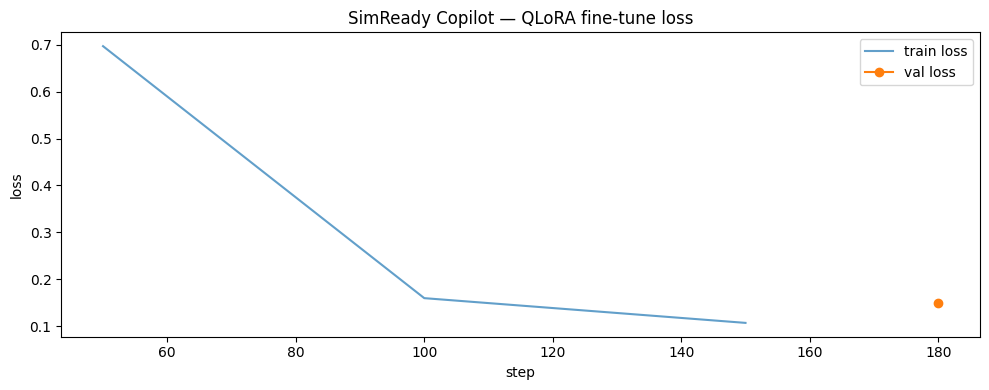

Loss curve saved to Drive.


In [ ]:
# Loss curve
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_steps  = [e["step"] for e in log_history if "loss" in e]
train_losses = [e["loss"] for e in log_history if "loss" in e]
eval_steps   = [e["step"] for e in log_history if "eval_loss" in e]
eval_losses  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

plt.figure(figsize=(10, 4))
plt.plot(train_steps, train_losses, label="train loss", alpha=0.7)
if eval_losses:
    plt.plot(eval_steps, eval_losses, label="val loss", marker="o")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("SimReady Copilot — QLoRA fine-tune loss")
plt.legend()
plt.tight_layout()
plt.savefig(str(DRIVE_ROOT / "loss_curve.png"), dpi=120)
plt.show()
print("Loss curve saved to Drive.")

## 9 · Save LoRA adapter

In [ ]:
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"LoRA adapter saved → {ADAPTER_DIR}")

# List saved files
import os
for f in os.listdir(ADAPTER_DIR):
    size_mb = os.path.getsize(os.path.join(ADAPTER_DIR, f)) / 1e6
    print(f"  {f:<40} {size_mb:.1f} MB")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/SimReady/lora_adapter/tokenizer_config.json.


LoRA adapter saved → /content/drive/MyDrive/SimReady/lora_adapter
  README.md                                0.0 MB
  adapter_model.safetensors                119.8 MB
  adapter_config.json                      0.0 MB
  chat_template.jinja                      0.0 MB
  tokenizer_config.json                    0.0 MB
  tokenizer.json                           11.4 MB


## 10 · Quick inference check

Sanity test: does the fine-tuned model still call `analyze_geometry` when given a STEP path?

In [ ]:
FastLanguageModel.for_inference(model)  # enable native 2x faster inference

test_messages = [
    {"role": "system", "content": "You are SimReady Copilot, an AI for FEA pre-processing."},
    {"role": "user",   "content": "What manufacturing issues does tests/data/smoke_box.step have?"},
]

prompt = to_chatml(test_messages) + "\n<|im_start|>assistant\n"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.1,
        do_sample=True,
    )

decoded = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)
print("Model output:")
print(decoded)

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

Model output:
Unfortunately, the file "tests/data/smoke_box.step" is a simple 3D model used for testing purposes and does not contain any real-world manufacturing issues. It is a small, simple model with no real-world scale or complexity.

If you need help with specific aspects of manufacturing or simulation related to this model, please provide more details about what you're looking for.
<|im_end|>


## 11 · (Optional) Push adapter to HuggingFace Hub

Set `HF_TOKEN` in Colab Secrets (`🔑` sidebar) before running.

In [ ]:
PUSH_TO_HUB = False   # set True when ready
HF_REPO     = "YOUR_HF_USERNAME/simready-copilot-lora"  # change this

if PUSH_TO_HUB:
    from google.colab import userdata
    import os
    os.environ["HUGGINGFACE_TOKEN"] = userdata.get("HF_TOKEN")
    model.push_to_hub(HF_REPO, token=userdata.get("HF_TOKEN"), private=True)
    tokenizer.push_to_hub(HF_REPO, token=userdata.get("HF_TOKEN"), private=True)
    print(f"Adapter pushed → https://huggingface.co/{HF_REPO}")
else:
    print("Hub push skipped. Set PUSH_TO_HUB = True and HF_REPO to enable.")

Hub push skipped. Set PUSH_TO_HUB = True and HF_REPO to enable.
